## Initial data screening & pre processing

In [ ]:
import nibabel as nib, numpy as np

# quick check to see how many classes we got in a patient; Slicer is only showing 3 classes in patient 9, should be 4
g = np.asarray(nib.load("data/segthor_part1/train/Patient_09/GT.nii.gz").dataobj)
vals, counts = np.unique(g, return_counts=True)
print(dict(zip(vals.astype(int), counts)))

{0: 39904945, 1: 75603, 2: 366127, 3: 23501}


In [11]:
img = nib.load("data/segthor_part1/train/Patient_09/GT.nii.gz")
print(type(img))                     # was ist das überhaupt für ein Objekt?
[print(a) for a in dir(img) if not a.startswith("_")]   # was kann es?
img.header                    # NIfTI-Header druckt sich lesbar aus


<class 'nibabel.nifti1.Nifti1Image'>
ImageArrayProxy
ImageSlicer
affine
as_reoriented
dataobj
extra
file_map
files_types
filespec_to_file_map
from_bytes
from_file_map
from_filename
from_image
from_stream
from_url
get_data
get_data_dtype
get_fdata
get_filename
get_qform
get_sform
header
header_class
in_memory
instance_to_filename
load
make_file_map
makeable
ndim
orthoview
path_maybe_image
rw
set_data_dtype
set_filename
set_qform
set_sform
shape
slicer
to_bytes
to_file_map
to_filename
to_stream
uncache
update_header
valid_exts


In [22]:
print(img.ndim)
print(img.shape)
print(img.affine)
print(img.header)

3
(512, 512, 163)
[[  -0.9765625     0.            0.          249.51171875]
 [   0.           -0.9765625     0.          437.51171875]
 [   0.            0.            2.         -490.1000061 ]
 [   0.            0.            0.            1.        ]]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 512 512 163   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1.        0.9765625 0.9765625 2.        0.        0.        0.
 0.       ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0


In [34]:
img = nib.load("data/segthor_part1/train/Patient_10/GT.nii.gz")
print(img.ndim)
print(img.shape)
print(img.affine)
print(img.header)

3
(512, 512, 163)
[[  -0.9765625     0.            0.          249.51171875]
 [   0.           -0.9765625     0.          437.51171875]
 [   0.            0.            2.         -490.1000061 ]
 [   0.            0.            0.            1.        ]]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3 512 512 163   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1.        0.9765625 0.9765625 2.        0.        0.        0.
 0.       ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0


In [ ]:
print(img.header.get_zooms())        # Spacing in mm, z.B. (0.97, 0.97, 2)
print(img.header.get_data_shape())   # (512, 512, 163)
print(img.header.get_data_dtype())   # uint8
print(img.header.get_xyzt_units())   # ('mm', 'unknown') — Einheiten-Sanity-Check
print(nib.aff2axcodes(img.affine))   # ('L','P','S') — Orientierung

(0.9765625, 0.9765625, 2.0)
(512, 512, 163)
uint8
('mm', 'unknown')
('L', 'P', 'S')


In [24]:
ct = nib.load("data/segthor_part1/train/Patient_10/Patient_10.nii.gz")
gt = nib.load("data/segthor_part1/train/Patient_10/GT.nii.gz")
print(np.allclose(ct.affine, gt.affine))
print(ct.shape == gt.shape, ct.header.get_data_dtype(), gt.header.get_data_dtype())

True
True int32 uint8


In [31]:
import nibabel as nib, numpy as np

img = nib.load("data/segthor_part1/train/Patient_09/Patient_09.nii.gz").get_fdata()   # das CT, float
lab = np.asarray(nib.load("data/segthor_part1/train/Patient_09/GT.nii.gz").dataobj)   # die Maske, uint8

for k, name in {1:"eso", 2:"heart", 3:"trachea", 4:"aorta"}.items():
    m = lab == k
    if m.any():
        print(f"{name:8s} median HU {np.median(img[m]):7.1f}  "
              f"min {img[m].min():7.1f}  max {img[m].max():7.1f}  n={m.sum()}")

eso      median HU   130.0  min  -793.0  max  1233.0  n=75603
heart    median HU   112.0  min  -957.0  max   464.0  n=366127
trachea  median HU  -985.0  min -1000.0  max   168.0  n=23501


In [32]:
import nibabel as nib, numpy as np

img = nib.load("data/segthor_part1/train/Patient_10/Patient_10.nii.gz").get_fdata()   # das CT, float
lab = np.asarray(nib.load("data/segthor_part1/train/Patient_10/GT.nii.gz").dataobj)   # die Maske, uint8

for k, name in {1:"eso", 2:"heart", 3:"trachea", 4:"aorta"}.items():
    m = lab == k
    if m.any():
        print(f"{name:8s} median HU {np.median(img[m]):7.1f}  "
              f"min {img[m].min():7.1f}  max {img[m].max():7.1f}  n={m.sum()}")

eso      median HU    39.0  min  -816.0  max   536.0  n=135968
heart    median HU    26.0  min  -971.0  max  1047.0  n=488311
trachea  median HU  -961.0  min -1000.0  max    78.0  n=19927


### examine class distribution, HU values, volumes per class for a single patient

In [ ]:
import numpy as np

img = nib.load("data/segthor_part1/train/Patient_10/Patient_10.nii.gz").get_fdata()   # CT, float
lab = np.asarray(nib.load("data/segthor_part1/train/Patient_10/GT.nii.gz").dataobj)   # mask, uint8

K = {0: "class0", 1: "class1", 2: "class2", 3: "class3"}

for k, name in K.items():
    m = lab == k
    if m.any():
        print(f"{name:8s} median HU {np.median(img[m]):7.1f} mean HU {np.mean(img[m]):7.1f} min HU {img[m].min():7.1f} max HU {img[m].max():7.1f} n={m.sum()}")

print(img.shape)
print(lab.shape)

print(f"max HU value {img.max()}")
print(f"min HU value {img.min()}")

#print(np.unique(lab))   # class labels
#print(np.unique(img))   # HU values


class0   median HU  -953.0 mean HU  -640.4 min HU -1000.0 max HU  3071.0 n=42085266
class1   median HU    39.0 mean HU    35.7 min HU  -816.0 max HU   536.0 n=135968
class2   median HU    26.0 mean HU    13.1 min HU  -971.0 max HU  1047.0 n=488311
class3   median HU  -961.0 mean HU  -803.2 min HU -1000.0 max HU    78.0 n=19927
(512, 512, 163)
(512, 512, 163)
max HU value 3071.0
min HU value -1000.0


### examine class distribution, HU values, volumes per class for all patients

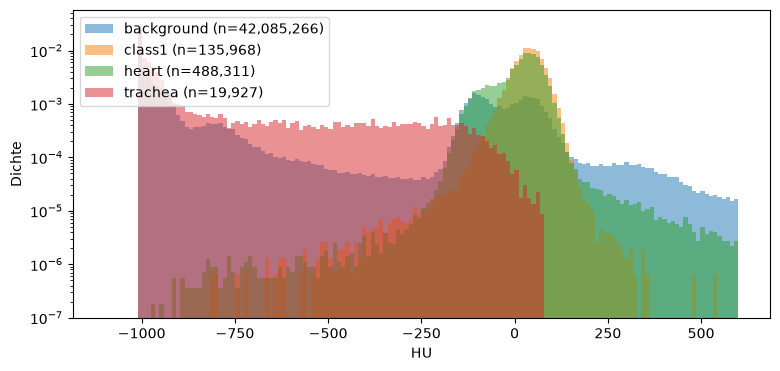

In [ ]:
# ein patient

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
names = {0: "background", 1: "class1", 2: "heart", 3: "trachea"}

for k, name in names.items():
    v = img[lab == k]
    ax.hist(v, bins=150, range=(-1100, 600), alpha=0.5,
            density=True, label=f"{name} (n={v.size:,})")

ax.set_xlabel("HU")
ax.set_ylabel("Dichte")
ax.set_yscale("log")
ax.legend()


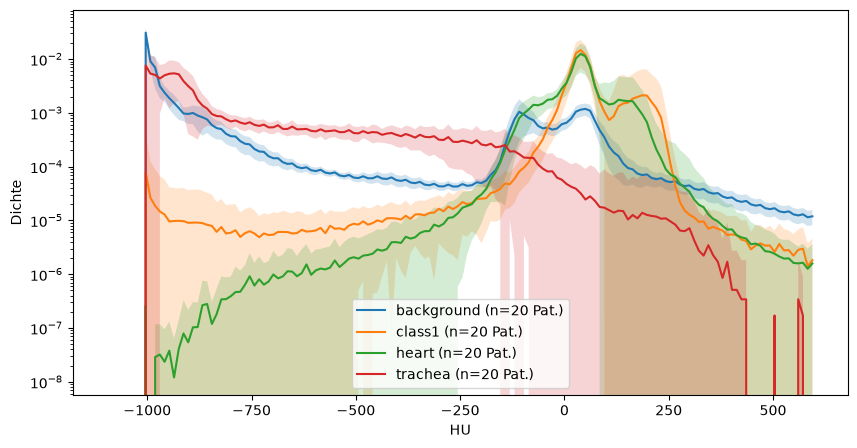

<Figure size 640x480 with 0 Axes>

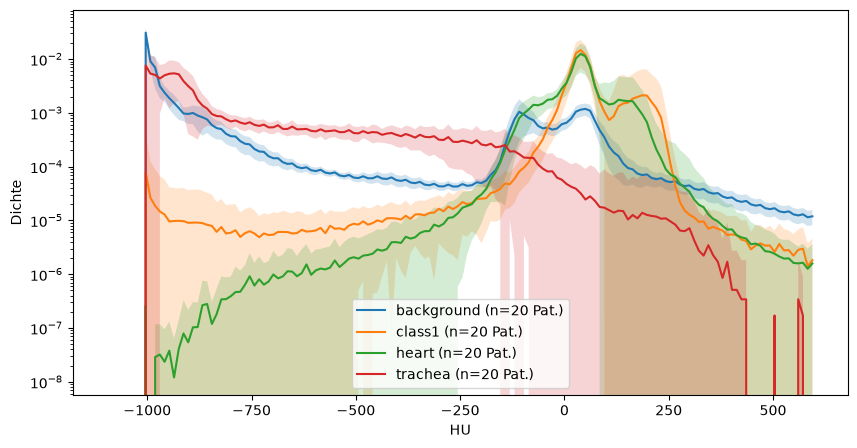

In [64]:
# all patients
from explore_segthor import find_pairs
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

bins = np.linspace(-1100, 600, 151)          # 150 Bins, fix für alle
centers = (bins[:-1] + bins[1:]) / 2
classes = {0: "background", 1: "class1", 2: "heart", 3: "trachea"}

# pro Klasse: Liste von normierten Histogrammen, eins pro Patient
hists = {k: [] for k in classes}
root = Path("data/segthor_part1/train")

for pid, ct_path, gt_path in find_pairs(root):
    img = nib.load(ct_path).get_fdata()
    lab = np.asarray(nib.load(gt_path).dataobj)
    for k in classes:
        v = img[lab == k]
        if v.size == 0:
            continue                          # Klasse fehlt bei diesem Patienten
        h, _ = np.histogram(v, bins=bins, density=True)
        hists[k].append(h)

# mitteln und Streuung
fig, ax = plt.subplots(figsize=(10, 5))
for k, name in classes.items():
    if not hists[k]:
        continue
    H = np.vstack(hists[k])                   # (n_patients, 150)
    mean, std = H.mean(0), H.std(0)
    ax.plot(centers, mean, label=f"{name} (n={len(hists[k])} Pat.)")
    ax.fill_between(centers, mean - std, mean + std, alpha=0.2)

ax.set_xlabel("HU"); ax.set_ylabel("Dichte"); ax.set_yscale("log"); ax.legend()

In [69]:
import pandas as pd

classes = {0: "background", 1: "class1", 2: "heart", 3: "trachea", 4: "aorta"}

hists = {k: [] for k in classes}
root = Path("data/segthor_part1/train")


rows = [] 
for pid, ct_path, gt_path in find_pairs(root):
    ct = nib.load(ct_path)
    img = ct.get_fdata()
    lab = np.asarray(nib.load(gt_path).dataobj)
    patient = {}
    
    patient["shape"] = img.shape
    patient["spacing"] = ct.header.get_zooms()
    for k, name in classes.items():
        mask = lab == k
        if mask.any():
            patient[str(name)+"_mean_HU"] = np.mean(img[mask])
            patient[str(name)+"_median_HU"] = np.median(img[mask])
            patient[str(name)+"_min_HU"] = img[mask].min()
            patient[str(name)+"_max_HU"] = img[mask].max()
            patient[str(name)+"_volume"] = mask.sum()

    rows.append(patient)

df = pd.DataFrame(rows)

In [71]:
df

,shape,spacing,background_mean_HU,background_median_HU,background_min_HU,background_max_HU,background_volume,class1_mean_HU,class1_median_HU,class1_min_HU,...,heart_mean_HU,heart_median_HU,heart_min_HU,heart_max_HU,heart_volume,trachea_mean_HU,trachea_median_HU,trachea_min_HU,trachea_max_HU,trachea_volume
0,"(512, 512, 229)","(0.9765625, 0.9765625, 2.0)",-752.602305,-994.0,-1000.0,3071.0,59494402,21.189163,33.0,-1000.0,...,11.475414,26.0,-585.0,400.0,365637,-882.397451,-972.0,-1000.0,-44.0,32009
1,"(512, 512, 246)","(0.976562, 0.976562, 2.5)",-695.344123,-966.0,-1000.0,26613.0,64008218,141.369539,164.0,-879.0,...,110.373596,133.0,-584.0,1103.0,359613,-798.037921,-886.0,-995.0,-97.0,14240
2,"(512, 512, 147)","(0.976562, 0.976562, 2.5)",-743.338537,-978.0,-1000.0,25292.0,38285585,159.254817,194.0,-821.0,...,97.452944,113.0,-547.0,1584.0,183705,-776.418013,-881.0,-996.0,114.0,12624
3,"(512, 512, 158)","(0.976562, 0.976562, 2.5)",-723.439369,-969.0,-1000.0,4551.0,40898092,42.825964,44.0,-960.0,...,23.663736,38.0,-670.0,701.0,330508,-865.352771,-922.0,-1000.0,-97.0,21796
4,"(512, 512, 284)","(0.9765625, 0.9765625, 2.0)",-802.456242,-996.0,-1000.0,3071.0,73808603,-21.471855,40.0,-1000.0,...,33.528759,39.0,-810.0,709.0,454409,-717.386650,-964.0,-1000.0,3071.0,25858
5,"(512, 512, 199)","(0.976562, 0.976562, 2.5)",-750.411066,-990.0,-1000.0,3071.0,51632746,168.993604,191.0,-1000.0,...,107.001876,125.0,-894.0,435.0,377459,-866.544075,-968.0,-1000.0,85.0,17459
6,"(512, 512, 179)","(0.9765625, 0.9765625, 2.0)",-727.998555,-985.0,-1000.0,3059.0,46427909,25.750436,32.0,-953.0,...,12.165962,25.0,-722.0,158.0,365861,-820.082222,-953.0,-1000.0,83.0,14777
7,"(512, 512, 171)","(0.976562, 0.976562, 2.5)",-771.199909,-993.0,-1000.0,3071.0,44455098,45.553975,46.0,-887.0,...,29.983109,40.0,-1000.0,1612.0,254685,-895.436588,-979.0,-1000.0,108.0,17268
8,"(512, 512, 154)","(0.976562, 0.976562, 2.5)",-789.646542,-995.0,-1000.0,3071.0,39904945,113.207399,130.0,-793.0,...,94.437586,112.0,-957.0,464.0,366127,-877.265265,-985.0,-1000.0,168.0,23501
9,"(512, 512, 163)","(0.9765625, 0.9765625, 2.0)",-640.392173,-953.0,-1000.0,3071.0,42085266,35.740954,39.0,-816.0,...,13.106281,26.0,-971.0,1047.0,488311,-803.204547,-961.0,-1000.0,78.0,19927


In [73]:
# table over all HU values over all patients; median, mean, std, percentiles

df.describe()


,background_mean_HU,background_median_HU,background_min_HU,background_max_HU,background_volume,class1_mean_HU,class1_median_HU,class1_min_HU,class1_max_HU,class1_volume,heart_mean_HU,heart_median_HU,heart_min_HU,heart_max_HU,heart_volume,trachea_mean_HU,trachea_median_HU,trachea_min_HU,trachea_max_HU,trachea_volume
count,20.000000,20.000000,20.0,20.000000,2.000000e+01,20.000000,20.00000,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,-743.982344,-978.500000,-1000.0,9446.350000,4.840509e+07,58.620832,70.80000,-880.70000,985.750000,117895.650000,40.919544,54.700000,-780.300000,1230.750000,374801.050000,-800.231553,-915.550000,-998.050000,221.050000,18288.650000
std,52.430466,18.406235,0.0,9369.337522,9.380860e+06,54.086529,59.98298,115.00119,472.868611,50522.709648,36.853897,38.744915,160.984177,1455.813351,137321.926491,73.798545,65.422896,3.831655,678.956822,7033.323399
min,-823.201940,-996.000000,-1000.0,1892.000000,3.828558e+07,-21.471855,31.00000,-1000.00000,260.000000,53254.000000,-0.474780,22.000000,-1000.000000,158.000000,183705.000000,-895.436588,-985.000000,-1000.000000,-97.000000,7209.000000
25%,-785.540075,-993.250000,-1000.0,3071.000000,4.212790e+07,28.310236,34.00000,-990.75000,706.750000,83556.000000,13.725711,29.750000,-896.750000,504.500000,266055.000000,-865.650597,-964.250000,-1000.000000,21.000000,14620.250000
50%,-748.999266,-982.000000,-1000.0,3071.000000,4.544150e+07,37.131662,40.00000,-894.00000,864.000000,110291.000000,27.775139,38.500000,-799.000000,914.000000,365749.000000,-809.743190,-925.500000,-1000.000000,82.500000,16948.000000
75%,-717.560509,-971.250000,-1000.0,14852.000000,5.214222e+07,62.467331,67.00000,-810.25000,1298.250000,143459.000000,48.755966,59.500000,-648.750000,1355.250000,455935.750000,-770.750708,-886.000000,-999.000000,128.000000,20551.000000
max,-628.993725,-921.000000,-1000.0,31743.000000,7.380860e+07,168.993604,194.00000,-678.00000,2264.000000,259929.000000,110.373596,133.000000,-517.000000,7095.000000,767246.000000,-652.307034,-749.000000,-988.000000,3071.000000,36293.000000


In [ ]:
# plan für morgen:
# 5 steps data screening:
# Header — Shape, Spacing, Orientierung, Datentyp.
# Skalare Statistiken — min/max/mean der Intensitäten, np.unique auf Labels, Voxelzahlen pro Klasse. Eine Zahl pro Patient, in eine Tabelle.
# Histogramme — HU-Verteilung 
# Projektionen — arr.max(axis=2) --> 2D-Bild pro Volumen. ganzer datensatz in einem raster
# (Einzelne Slices mit Overlay — teuer in Aufmerksamkeit, deshalb zuletzt und gezielt.)

# aus den ergebnissen kann ich ableiten wie meine daten vorliegen und was ich anpassen muss um sie verarbeitbar zu machen. das ist dann meine pre_processing.py

# was war der "fehler" den er eingebaut hat; irgendwas hatte er in der lecture erwähnt, ich habs leider vergessen

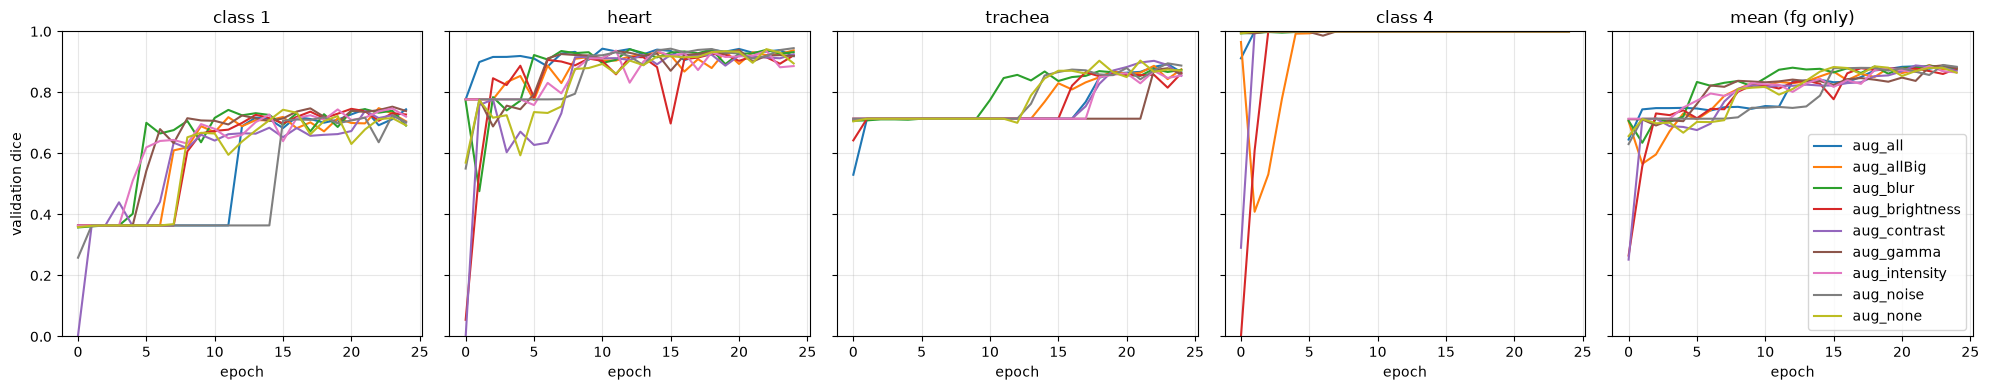

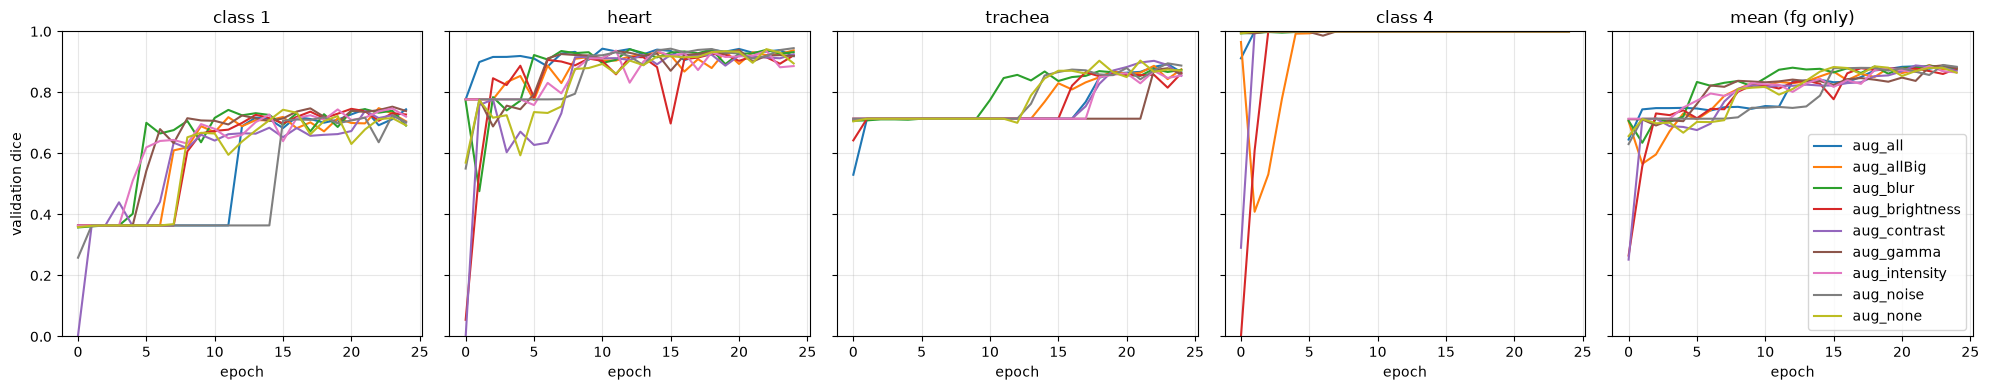

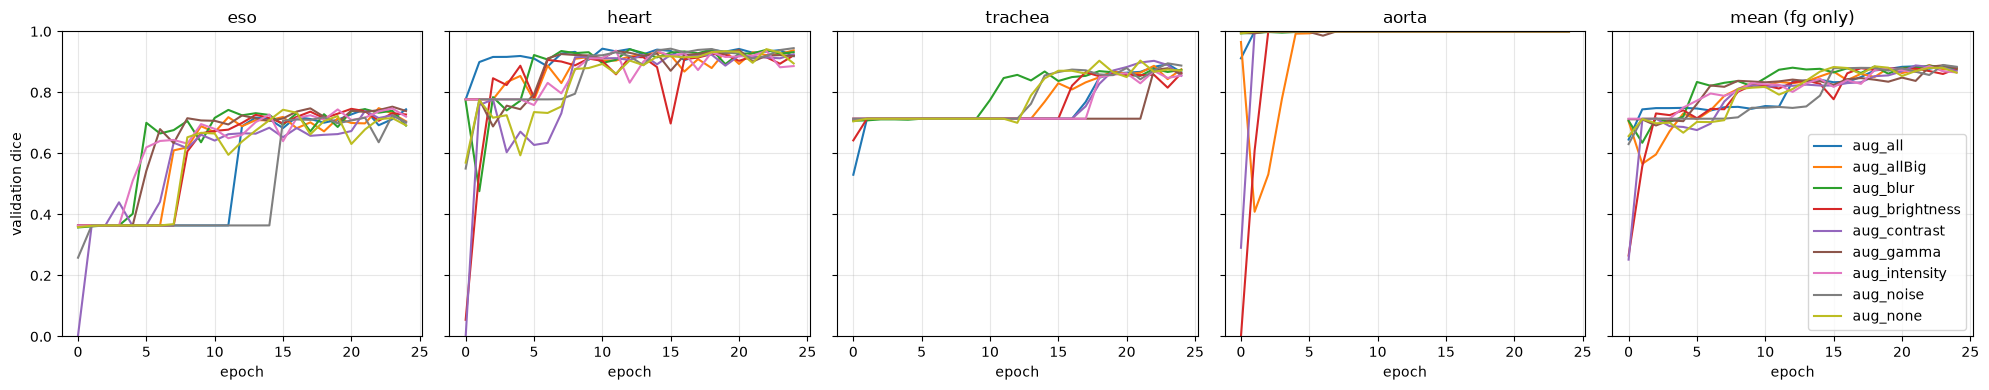

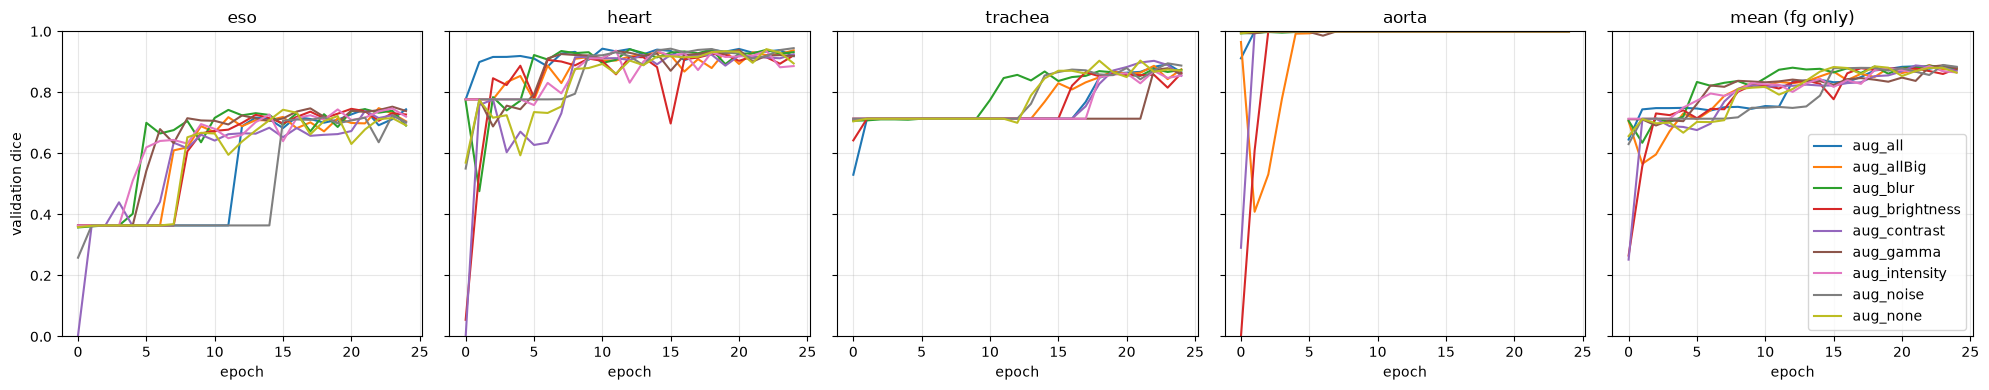

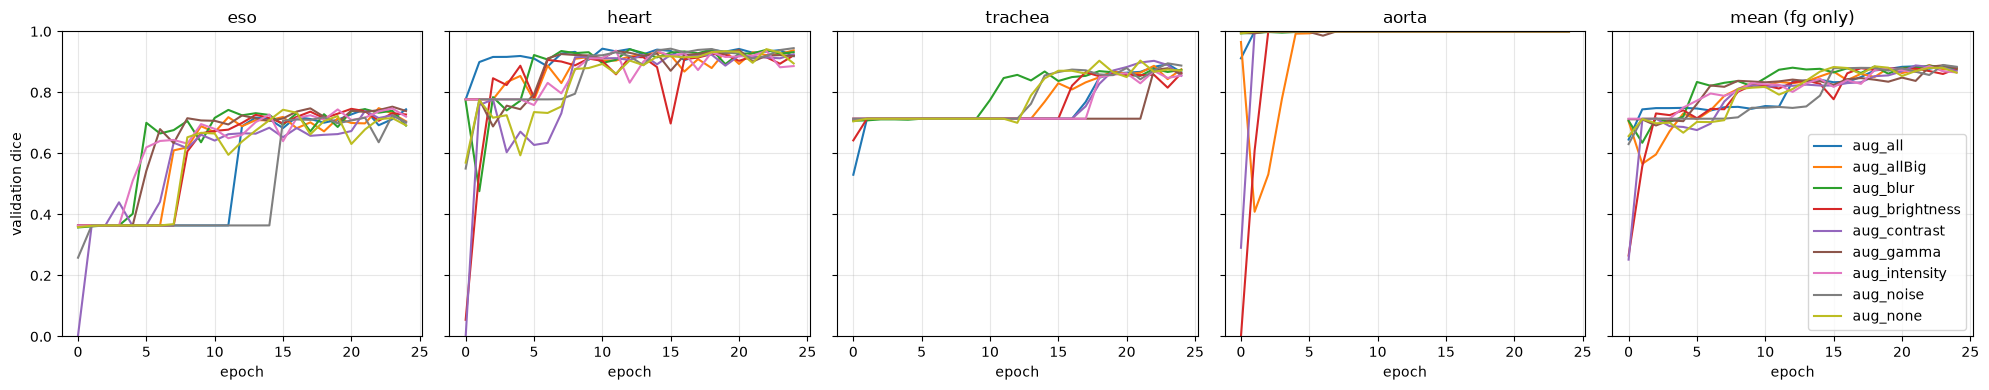

In [76]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

results = Path("results")
names = {1: "eso", 2: "heart", 3: "trachea", 4: "aorta"}

fig, axes = plt.subplots(1, len(names) + 1, figsize=(4 * (len(names) + 1), 4), sharey=True)

for run_dir in sorted(results.iterdir()):
    f = run_dir / "dice_val.npy"
    if not f.is_file():
        print(f"skipping {run_dir.name}: no dice_val.npy")
        continue
    d = np.load(f)
    if d.ndim != 3 or d.shape[2] <= max(names):
        print(f"skipping {run_dir.name}: unexpected shape {d.shape}")
        continue
    d = d[d.any(axis=(1, 2))]
    if len(d) == 0:
        print(f"skipping {run_dir.name}: no completed epoch")
        continue

    for ax, k in zip(axes, names):
        ax.plot(d[:, :, k].mean(axis=1), label=run_dir.name)

    axes[-1].plot(d[:, :, 1:].mean(axis=(1, 2)), label=run_dir.name)

for ax, name in zip(axes, list(names.values()) + ["mean (fg only)"]):
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("validation dice")
axes[0].set_ylim(0, 1)
axes[-1].legend()
fig.tight_layout()
plt.show()

In [13]:
import nibabel as nib, numpy as np

ct = nib.load("data/segthor_part1/train/Patient_07/Patient_07.nii.gz")
img = nib.load("data/segthor_part1/train/Patient_07/Patient_07.nii.gz").get_fdata()  
gt2 = np.asarray(nib.load("data/segthor_part1/train/Patient_07/GT2.nii.gz").dataobj) 
gt = np.asarray(nib.load("data/segthor_part1/train/Patient_07/GT.nii.gz").dataobj)   


print(f"gt class1 MEAN: {np.mean(img[gt==1]):7.1f} gt class1 MEDIAN: {np.median(img[gt==1]):7.1f}")
print(f"gt2 class1 MEAN: {np.mean(img[gt2==1]):7.1f} gt2 class1 MEDIAN: {np.median(img[gt2==1]):7.1f}")
print(f"gt2 class4 MEAN: {np.mean(img[gt2==4]):7.1f} gt2 class4 MEDIAN: {np.median(img[gt2==4]):7.1f}")


print(f"gt class1 VOLUME: {((gt==1).sum() * 1.88):7.1f} mm3 (n={(gt==1).sum():7.1f}) gt2 class1 VOLUME: {((gt2==1).sum() * 1.88):7.1f} mm3 (n={(gt2==1).sum():7.1f}) gt2 class4 VOLUME: {((gt2==4).sum() * 1.88):7.1f} mm3 (n={(gt2==4).sum():7.1f})")
print(f"sum VOLUME of gt2 class1 and class4 =  {(((gt2==1).sum()) + ((gt2==4).sum())) * 1.88} mm3 (n={((gt2==1).sum()) + ((gt2==4).sum())})")

gt class1 MEAN:    25.8 gt class1 MEDIAN:    32.0
gt2 class1 MEAN:    -2.7 gt2 class1 MEDIAN:    19.0
gt2 class4 MEAN:    33.8 gt2 class4 MEDIAN:    34.0
gt class1 VOLUME: 216630.5 mm3 (n=115229.0) gt2 class1 VOLUME: 47701.2 mm3 (n=25373.0) gt2 class4 VOLUME: 168929.3 mm3 (n=89856.0)
sum VOLUME of gt2 class1 and class4 =  216630.52 mm3 (n=115229)


In [15]:
import nibabel as nib, numpy as np

ct = nib.load("data/segthor_part1/train/Patient_07/Patient_07.nii.gz")
img = nib.load("data/segthor_part1/train/Patient_07/Patient_07.nii.gz").get_fdata()  
gt2 = np.asarray(nib.load("data/segthor_part1/train/Patient_07/GT2.nii.gz").dataobj) 
gt = np.asarray(nib.load("data/segthor_part1/train/Patient_07/GT.nii.gz").dataobj)   

VOXEL_MM3 = 1.88
MM3_PER_ML = 1000

# masks
m1_old = gt == 1
m1_new = gt2 == 1
m4_new = gt2 == 4

# voxel counts
n1_old, n1_new, n4_new = m1_old.sum(), m1_new.sum(), m4_new.sum()
n_merged = n1_new + n4_new

# intensity statistics
mean1_old, med1_old = img[m1_old].mean(), np.median(img[m1_old])
mean1_new, med1_new = img[m1_new].mean(), np.median(img[m1_new])
mean4_new, med4_new = img[m4_new].mean(), np.median(img[m4_new])

# volumes in ml
ml1_old = n1_old * VOXEL_MM3 / MM3_PER_ML
ml1_new = n1_new * VOXEL_MM3 / MM3_PER_ML
ml4_new = n4_new * VOXEL_MM3 / MM3_PER_ML
ml_merged = n_merged * VOXEL_MM3 / MM3_PER_ML

print(f"gt  eso   MEAN: {mean1_old:7.1f}  MEDIAN: {med1_old:7.1f}")
print(f"gt2 eso   MEAN: {mean1_new:7.1f}  MEDIAN: {med1_new:7.1f}")
print(f"gt2 aorta   MEAN: {mean4_new:7.1f}  MEDIAN: {med4_new:7.1f}")
print()
print(f"gt  eso   VOLUME: {ml1_old:7.1f} ml  (n={n1_old:8d})")
print(f"gt2 eso   VOLUME: {ml1_new:7.1f} ml  (n={n1_new:8d})")
print(f"gt2 aorta   VOLUME: {ml4_new:7.1f} ml  (n={n4_new:8d})")
print(f"gt2 eso and aorta  VOLUME: {ml_merged:7.1f} ml  (n={n_merged:8d})")

gt  eso   MEAN:    25.8  MEDIAN:    32.0
gt2 eso   MEAN:    -2.7  MEDIAN:    19.0
gt2 aorta   MEAN:    33.8  MEDIAN:    34.0

gt  eso   VOLUME:   216.6 ml  (n=  115229)
gt2 eso   VOLUME:    47.7 ml  (n=   25373)
gt2 aorta   VOLUME:   168.9 ml  (n=   89856)
gt2 eso and aorta  VOLUME:   216.6 ml  (n=  115229)


In [ ]:
ct = nib.load("data/segthor_part1/train/Patient_07/Patient_07.nii.gz")

ct.header.get_zooms() # 0.97,0.97,2 --> mm^3=1,88

(np.float32(0.9765625), np.float32(0.9765625), np.float32(2.0))

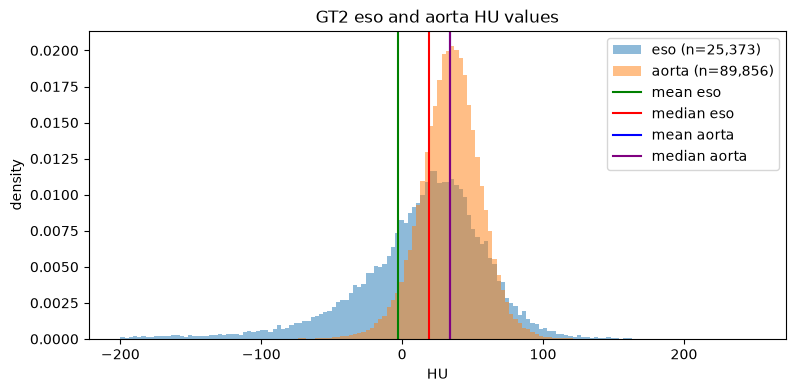

In [21]:
img = nib.load("data/segthor_part1/train/Patient_07/Patient_07.nii.gz").get_fdata()  
gt2 = np.asarray(nib.load("data/segthor_part1/train/Patient_07/GT2.nii.gz").dataobj) 
gt = np.asarray(nib.load("data/segthor_part1/train/Patient_07/GT.nii.gz").dataobj)   

# masks
m1_old = gt == 1
m1_new = gt2 == 1
m4_new = gt2 == 4

mean1_old, med1_old = img[m1_old].mean(), np.median(img[m1_old])
mean1_new, med1_new = img[m1_new].mean(), np.median(img[m1_new])
mean4_new, med4_new = img[m4_new].mean(), np.median(img[m4_new])

fig, ax = plt.subplots(figsize=(9, 4))

names = {1: "eso", 4: "aorta"}
for k, name in names.items():
    v = img[gt2 == k]
    ax.hist(v, bins=150, range=(-200, 250), alpha=0.5,
            density=True, label=f"{name} (n={v.size:,})")

plt.axvline(x = mean1_new, color = 'g', label = "mean eso")
plt.axvline(x = med1_new, color = 'r', label = "median eso")

plt.axvline(x = mean4_new, color = 'blue', label = "mean aorta")
plt.axvline(x = med4_new, color = 'purple', label = "median aorta")


ax.set_xlabel("HU")
ax.set_ylabel("density")
#ax.set_yscale("log")
plt.title("GT2 eso and aorta HU values")
ax.legend()


so apparently a seperation by HU value does not work. but: the structures are seperated geometrically (or touch very little). therefore we can use that information to seperate the classes

In [23]:
from scipy import ndimage

merged = gt == 1
comp, n = ndimage.label(merged)          # 3D, 6-connectivity by default
print(f"{n} components")

for c in range(1, n + 1):
    m = comp == c
    idx = np.argwhere(m)
    print(f"  comp {c}: {m.sum():7d} vox  medHU {np.median(img[m]):6.1f}  "
          f"z {idx[:,2].min()}-{idx[:,2].max()}")
    

1 components
  comp 1:  115229 vox  medHU   32.0  z 26-164


In [24]:
from skimage.segmentation import watershed

eroded = ndimage.binary_erosion(merged, iterations=2)
markers, n = ndimage.label(eroded)
print(f"{n} markers after erosion")

# grow the markers back into the full mask
split = watershed(np.zeros_like(merged, dtype=np.uint8), markers, mask=merged)

2 markers after erosion


In [25]:
split.shape

(512, 512, 179)

In [51]:
gt_fixed = gt.copy()
gt_fixed[split == 4] = 4

print(len(gt))
print(len(gt_fixed))
print(np.unique(gt_fixed))

512
512
[0 1 2 3 4]


In [56]:
from explore_segthor import find_pairs

root = Path("data/segthor_part1/train")

for pid, ct_path, gt_path in find_pairs(root):
    ct = nib.load(ct_path)
    img = ct.get_fdata()
    gt = np.asarray(nib.load(gt_path).dataobj)
    
    merged = gt == 1

    eroded = ndimage.binary_erosion(merged, iterations=2)
    markers, n = ndimage.label(eroded)
    print(f"patient_{pid}: {n} markers after erosion")

print("done")

patient_Patient_01: 2 markers after erosion
patient_Patient_02: 2 markers after erosion
patient_Patient_03: 6 markers after erosion
patient_Patient_04: 5 markers after erosion
patient_Patient_05: 7 markers after erosion
patient_Patient_06: 4 markers after erosion
patient_Patient_07: 2 markers after erosion
patient_Patient_08: 6 markers after erosion
patient_Patient_09: 4 markers after erosion
patient_Patient_10: 2 markers after erosion
patient_Patient_11: 2 markers after erosion
patient_Patient_12: 4 markers after erosion
patient_Patient_13: 2 markers after erosion
patient_Patient_14: 5 markers after erosion
patient_Patient_15: 13 markers after erosion
patient_Patient_16: 2 markers after erosion
patient_Patient_17: 3 markers after erosion
patient_Patient_18: 2 markers after erosion
patient_Patient_19: 2 markers after erosion
patient_Patient_20: 1 markers after erosion
done


In [71]:
id = "20"

img = nib.load(f"data/segthor_part1/train/Patient_{id}/Patient_{id}.nii.gz").get_fdata()  
#gt2 = np.asarray(nib.load(f"data/segthor_part1/train/Patient_{id}/GT2.nii.gz").dataobj) 
gt = np.asarray(nib.load(f"data/segthor_part1/train/Patient_{id}/GT.nii.gz").dataobj)   

merged = gt == 1
comp, n = ndimage.label(merged)          # 3D, 6-connectivity by default
print(f"{n} components")

eroded = ndimage.binary_erosion(merged, iterations=1)
markers, n = ndimage.label(eroded)
print(f"{n} markers after erosion")

merged = gt == 1

eroded = ndimage.binary_erosion(merged, iterations=2)
markers, n = ndimage.label(eroded)
print(f"{n} markers after erosion")

1 components
1 markers after erosion
1 markers after erosion


In [ ]:
# fixed by doing only 1 erosion iteration: 6, 8, 9
# how to fix the rest?
# TODO: evaluate via Dice Loss calculation